## 5 - Report result

Comparison **baseline / batch / online** for greenhouse temperature forecasting U5.

Source : `outputs/xps_results.json` (run log) + `fold_result_*.json` (detail per fold).

In [7]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
_parent = Path().resolve().parent
if str(_parent) not in sys.path:
    sys.path.insert(0, str(_parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.results import load_journal, best_per_model, comparison_table
from src.plots import plot_metric_per_fold
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

cfg = yaml.safe_load(Path('../config/config.yaml').read_text())
JOURNAL = cfg['path_xps']   # ../outputs/xps_results.json
BASELINE = 'naive_24h'

# ⚠️ The average R² per fold is misleading.

journal = load_journal(JOURNAL)

best = best_per_model(journal)
cols = ['model', 'date', 
        'metrics_mean.MAE', 
        'metrics_mean.RMSE', 
        'metrics_mean.MAPE']
best[cols].sort_values('metrics_mean.MAE').reset_index(drop=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,model,date,metrics_mean.MAE,metrics_mean.RMSE,metrics_mean.MAPE
0,Ridge_Poly2,2026-06-11 05:43,2.0370,2.5818,9.4556
1,LightGBM,2026-06-11 05:43,2.3301,2.9912,10.8092
2,RandomForest,2026-06-11 05:43,2.4771,3.2042,11.7252
3,river,2026-06-13 04:29,2.7484,3.4214,13.4401
4,river_sgd,2026-06-11 05:44,2.7487,3.4191,13.4104
5,naive_24h,2026-06-11 05:43,3.1139,4.0931,13.9169
6,Lasso,2026-06-11 05:42,3.1606,3.9756,14.7051
7,Ridge,2026-06-11 05:42,3.2464,3.9867,15.5160
8,LinearRegression,2026-06-11 05:42,3.2501,3.9894,15.5425


In [2]:
# table GLOBAL metrics
# ⚠️ Metrics recalculated on the concatenated predictions of all folds
# (correct R²) + relative deviation of MAE vs baseline.
table = comparison_table(JOURNAL, baseline_model=BASELINE)
table.round(3)

,model,date,MAE,RMSE,R2,MAPE,n,global,vs_baseline_%
0,Ridge_Poly2,2026-06-11 05:43,1.891,2.586,0.958,8.803,533,True,-32.3
1,LightGBM,2026-06-11 05:43,2.172,3.125,0.938,10.019,533,True,-22.2
2,RandomForest,2026-06-11 05:43,2.362,3.415,0.926,10.999,533,True,-15.5
3,river_sgd,2026-06-11 05:44,2.502,3.472,0.923,12.230,536,True,-10.4
4,river,2026-06-13 04:29,2.515,3.422,0.925,12.171,536,True,-10.0
5,naive_24h,2026-06-11 05:43,2.793,4.512,0.870,12.338,536,True,0.0
6,Lasso,2026-06-11 05:42,2.896,3.983,0.899,13.452,533,True,3.7
7,Ridge,2026-06-11 05:42,2.975,3.976,0.900,14.183,533,True,6.5
8,LinearRegression,2026-06-11 05:42,2.979,3.979,0.899,14.207,533,True,6.6


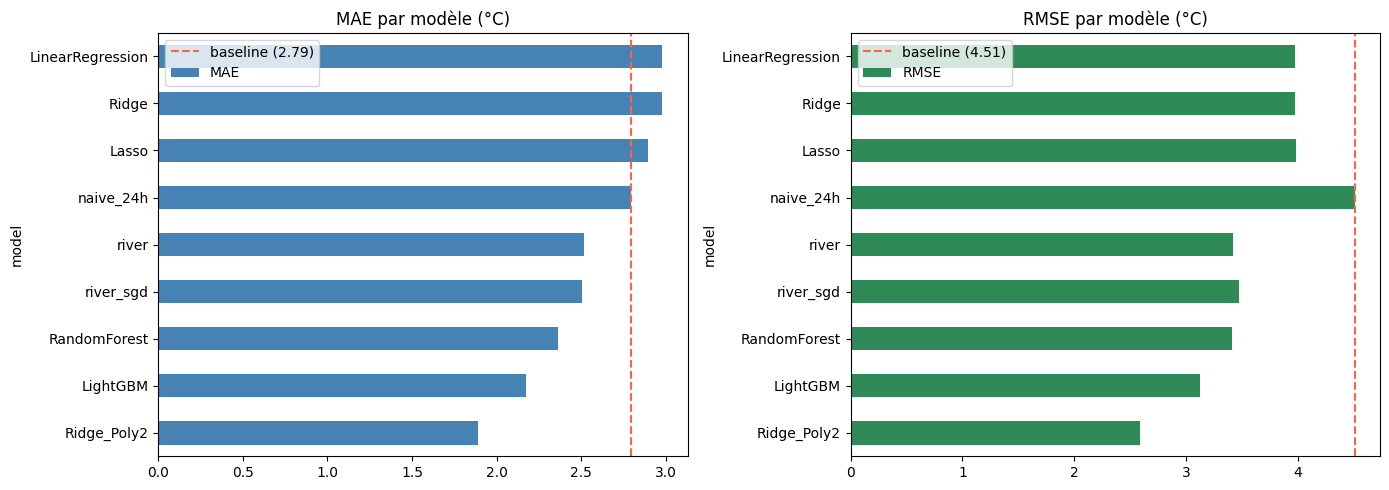

In [3]:
# Plot to viz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
base_mae  = table.loc[table['model'] == BASELINE, 'MAE'].iloc[0]
base_rmse = table.loc[table['model'] == BASELINE, 'RMSE'].iloc[0]

table.set_index('model')['MAE'].plot.barh(ax=axes[0], color='steelblue')
axes[0].axvline(base_mae, color='tomato', linestyle='--', label=f'baseline ({base_mae:.2f})')
axes[0].set_title('MAE par modèle (°C)'); axes[0].legend()

table.set_index('model')['RMSE'].plot.barh(ax=axes[1], color='seagreen')
axes[1].axvline(base_rmse, color='tomato', linestyle='--', label=f'baseline ({base_rmse:.2f})')
axes[1].set_title('RMSE par modèle (°C)'); axes[1].legend()

plt.tight_layout()
plt.show()

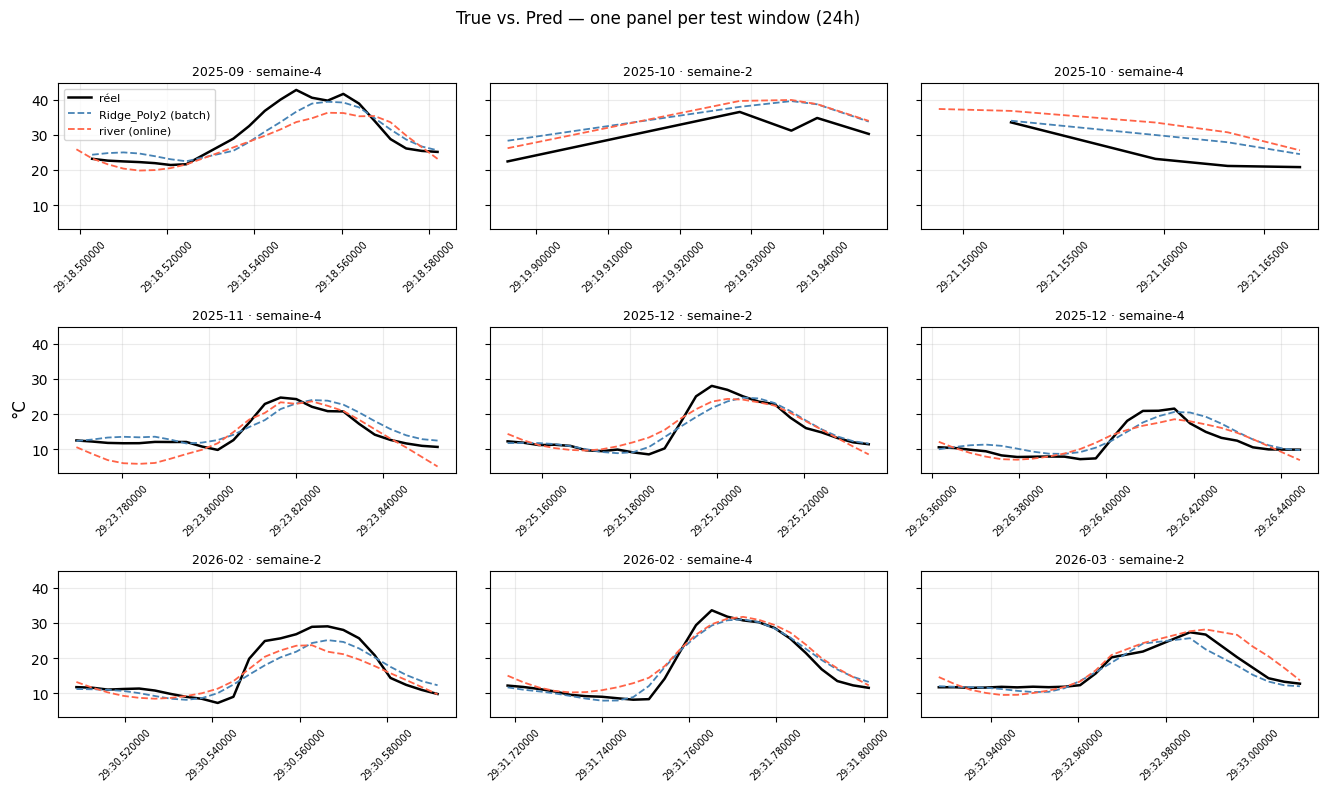

In [5]:
# Online vs batch, test by test windows
def load_folds(model_name, journal):
    """
    {Split: {'df': DataFrame(ts, y_test, y_pred), 'label': 'Month · Window'}}
    best model, fold structure (no concat)
    """
    valid = journal[journal['fold_result'].apply(lambda p: Path(p).exists())]
    run = best_per_model(valid)
    fold_path = run.loc[run['model'] == model_name, 'fold_result'].iloc[0]
    folds = json.loads(Path(fold_path).read_text(encoding='utf-8'))
    out = {}
    for f in folds:
        df = pd.DataFrame({
            'ts':     pd.to_datetime(f['timestamp']),
            'y_test': f['y_test'],
            'y_pred': f['y_pred'],
        }).sort_values('ts')
        out[f['Split']] = {'df': df, 'label': f"{f['Month']} · {f['Window']}"}
    return out

batch_model  = 'Ridge_Poly2'
online_model = 'river'

fb = load_folds(batch_model, journal)
fo = load_folds(online_model, journal)

# By default = last N folds (recent drift) are shown, None = all
n_last = 9
splits = sorted(fb)
if n_last:
    splits = splits[-n_last:]

ncols = 3
nrows = int(np.ceil(len(splits) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 2.6 * nrows),
                         sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, sp in zip(axes, splits):
    b = fb[sp]['df']
    ax.plot(b['ts'], b['y_test'], color='black',     lw=1.8, label='réel')
    ax.plot(b['ts'], b['y_pred'], color='steelblue', lw=1.3, ls='--',
            label=f'{batch_model} (batch)')
    if sp in fo:
        o = fo[sp]['df']
        ax.plot(o['ts'], o['y_pred'], color='tomato', lw=1.3, ls='--',
                label=f'{online_model} (online)')
    ax.set_title(fb[sp]['label'], fontsize=9)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.grid(alpha=0.25)

for ax in axes[len(splits):]:
    ax.axis('off')

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('True vs. Pred — one panel per test window (24h)', y=1.01)
fig.supylabel('°C')
fig.tight_layout()
plt.show()

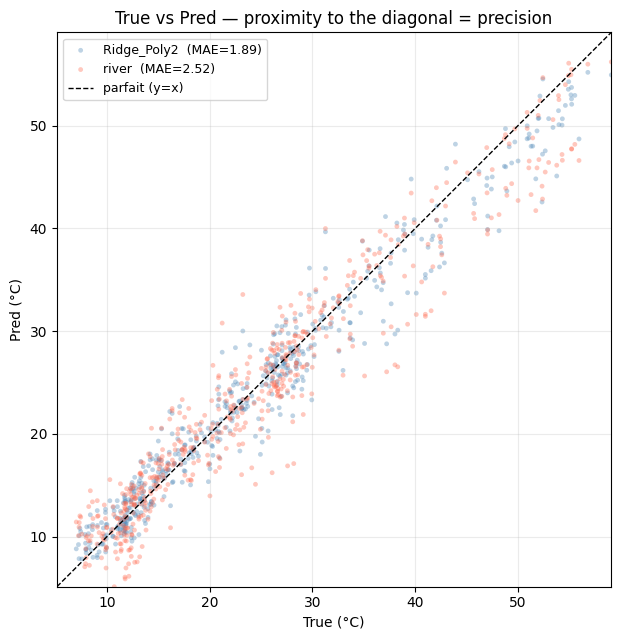

In [6]:
# Plot true vs pred, systematic bias (over- / underestimation)
def load_points(model_name, journal):
    """
    All the concatenated (y_test, y_pred) values of a model, for the cloud
    """
    folds = load_folds(model_name, journal)
    df = pd.concat([f['df'] for f in folds.values()], ignore_index=True)
    return df['y_test'].values, df['y_pred'].values


scatter_models = {batch_model: 'steelblue', online_model: 'tomato'}

fig, ax = plt.subplots(figsize=(6.5, 6.5))
lo, hi = np.inf, -np.inf
for name, color in scatter_models.items():
    yt, yp = load_points(name, journal)
    mae = np.mean(np.abs(yp - yt))
    ax.scatter(yt, yp, s=12, alpha=0.35, color=color, edgecolors='none',
               label=f'{name}  (MAE={mae:.2f})')
    lo, hi = min(lo, yt.min(), yp.min()), max(hi, yt.max(), yp.max())

ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--', label='parfait (y=x)')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('True (°C)')
ax.set_ylabel('Pred (°C)')
ax.set_title('True vs Pred — proximity to the diagonal = precision')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

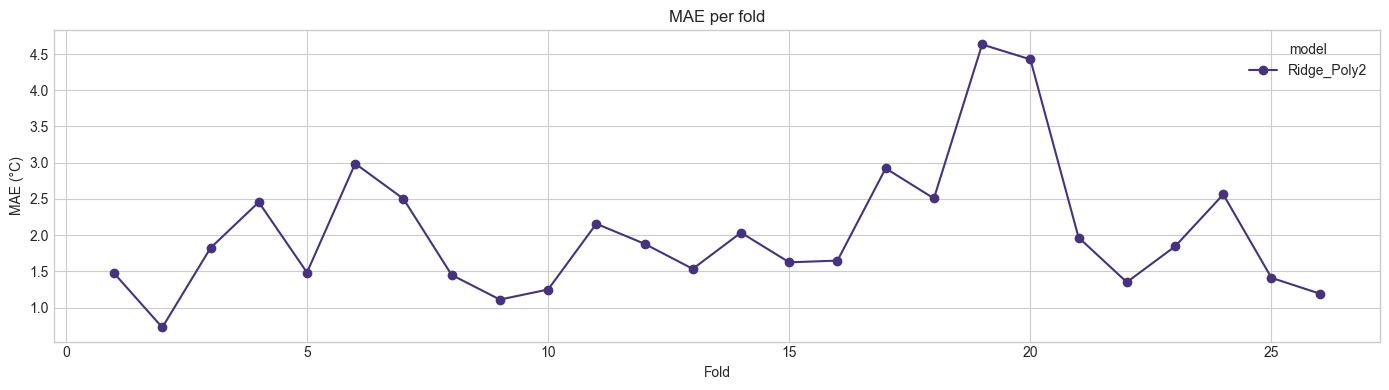

In [8]:
scores = pd.read_json('../outputs/fold_result_Ridge_Poly2.json')

plot_metric_per_fold(scores, metric="MAE")
plt.show()

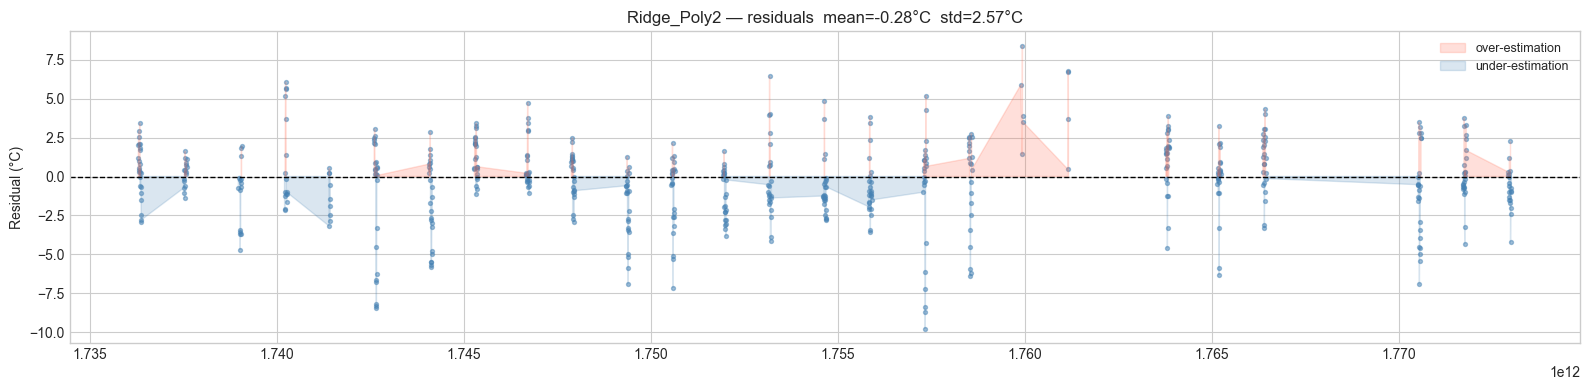

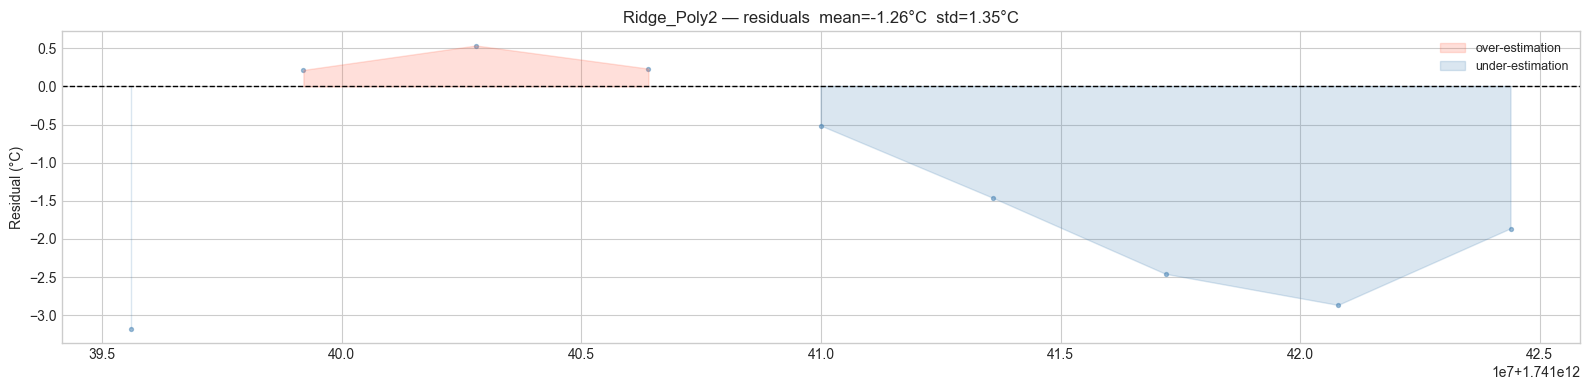

In [10]:
from src.plots import plot_residuals_timeline

plot_residuals_timeline(scores)

plot_residuals_timeline(scores, selected_folds=[5])  # [1, 3]
plt.show()

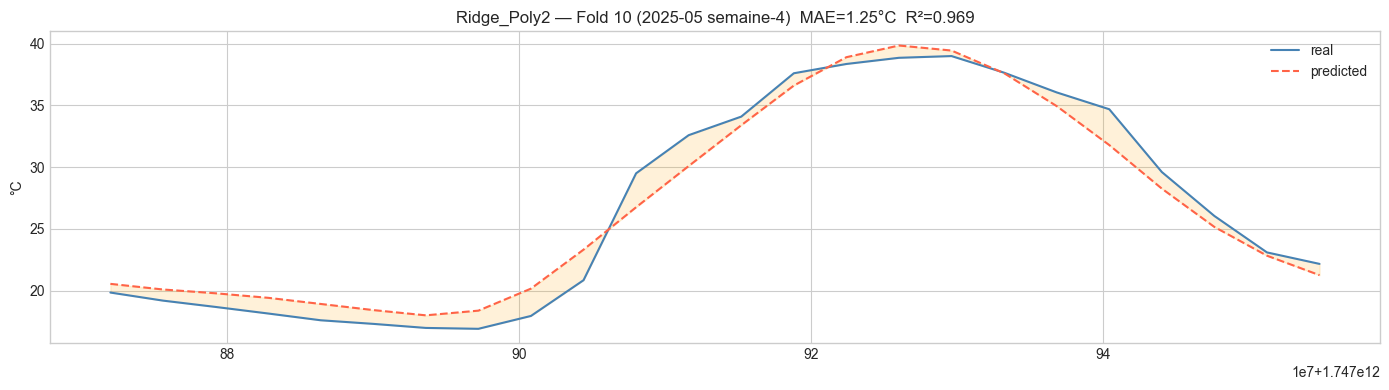

In [11]:
from src.plots import plot_fold_prediction

plot_fold_prediction(scores, split=10)
# plot_fold_prediction(scores, split=[1, 3, 10], model="Ridge_Poly2")  # multi model
plt.show()

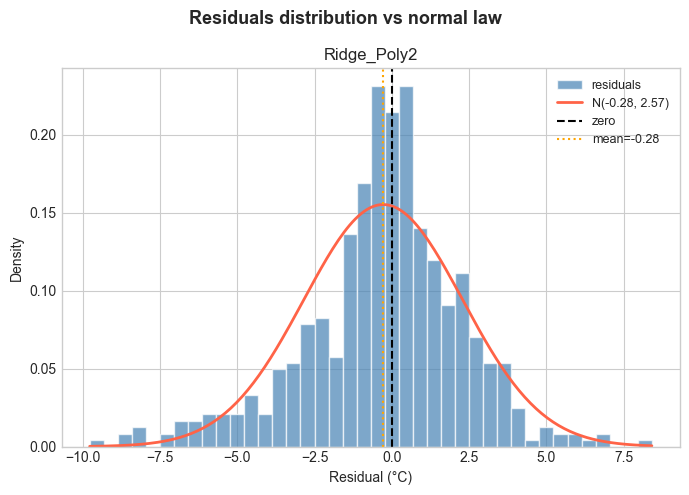

In [ ]:
from src.plots import plot_residuals_distribution

plot_residuals_distribution(scores)
plt.show()